In [45]:
import numpy as np
import pandas as pd

df = pd.read_csv("../data/df_with_2regimes.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

columns_to_drop = ['p_sigma', 'p_r', 'p_d', 'regime', 'regime_id']
df_hmm = df.drop(columns=columns_to_drop, errors='ignore').copy()

# Rename target to target_vol
if 'target' in df_hmm.columns:
    df_hmm = df_hmm.rename(columns={"target": "target_vol"})

# Log-transform realized variance
df_hmm["log_realized_variance"] = np.log(df_hmm["realized_variance"].clip(lower=1e-12))
# Next-day log variance target
df_hmm["target_log_var"] = df_hmm["log_realized_variance"].shift(-1)

# Realized variance lag/rolling features
df_hmm["rvar_1"]  = df_hmm["log_realized_variance"].shift(1)
df_hmm["rvar_2"]  = df_hmm["log_realized_variance"].shift(2)
df_hmm["rvar_3"]  = df_hmm["log_realized_variance"].shift(3)
df_hmm["rvar_7"]  = df_hmm["log_realized_variance"].rolling(window=7, min_periods=7).mean()
df_hmm["rvar_30"] = df_hmm["log_realized_variance"].rolling(window=30, min_periods=30).mean()


In [46]:
features = ["rvar_1", "rvar_30", "log_return"]

train_window = 365  # 1 year of trading days
n_obs = len(df_hmm)
regime_labels    = np.full(n_obs, -1, dtype=int)
prob_high_labels = np.full(n_obs, np.nan)
prob_high_t1     = np.full(n_obs, np.nan)

In [47]:
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler

def fit_hmm_and_decode(window_df):
    window_df = window_df.dropna(subset=features)
    X = window_df[features].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    model = GaussianHMM(
        n_components=2,
        covariance_type="diag",
        n_iter=1000,
        random_state=4211
    )
    model.fit(X_scaled)

    # Viterbi decode
    raw_states = model.predict(X_scaled)
    raw_probs  = model.predict_proba(X_scaled)  # shape: (365, 2)

    # Relabel: state 1 = high vol, state 0 = low vol
    rv = window_df["log_realized_variance"].values
    mean_rv_state0 = rv[raw_states == 0].mean()
    mean_rv_state1 = rv[raw_states == 1].mean()

    if mean_rv_state0 > mean_rv_state1:
        # State 0 is actually high vol — swap
        states = np.where(raw_states == 0, 1, 0)
        probs  = raw_probs[:, [1, 0]]
    else:
        states = raw_states
        probs  = raw_probs

    prob_high = probs[:, 1]

    # Forward-looking t+1 probability via transition matrix
    filtered_state_dist = probs[-1]       # state distribution at last timestep
    A = model.transmat_                   # transition matrix
    next_state_dist = filtered_state_dist @ A  # propagate one step forward

    if mean_rv_state0 > mean_rv_state1:
        prob_high_next = next_state_dist[0]   # high vol was state 0 originally
    else:
        prob_high_next = next_state_dist[1]

    return states, model, prob_high, prob_high_next

In [48]:
print(df_hmm[features].isna().sum()) #check

rvar_1         1
rvar_30       29
log_return     0
dtype: int64


In [49]:
import warnings
warnings.filterwarnings("ignore")

for t in range(train_window, n_obs):
    window = df_hmm.iloc[t - train_window : t]
    result = fit_hmm_and_decode(window)
    
    if result[0] is None:
        continue
        
    states, model, prob_high, prob_high_next = result

    regime_labels[t - 1]    = states[-1]
    prob_high_labels[t - 1] = prob_high[-1]
    prob_high_t1[t - 1]     = prob_high_next

    if (t - train_window) % 500 == 0:
        pct = 100 * (t - train_window) / (n_obs - train_window)
        print(f"  {t - train_window}/{n_obs - train_window} windows ({pct:.1f}%)")

print("Rolling HMM completed.")

  0/3153 windows (0.0%)
  500/3153 windows (15.9%)
  1000/3153 windows (31.7%)
  1500/3153 windows (47.6%)
  2000/3153 windows (63.4%)
  2500/3153 windows (79.3%)
  3000/3153 windows (95.1%)
Rolling HMM completed.


In [50]:
print("len(df_hmm):", len(df_hmm))
print("len(regime_labels):", len(regime_labels))

df_hmm["hmm_regime"]       = regime_labels
df_hmm["hmm_prob_high"]    = prob_high_labels
df_hmm["hmm_prob_high_t1"] = prob_high_t1

# Convert sentinel to missing
df_hmm["hmm_regime"] = df_hmm["hmm_regime"].replace(-1, np.nan)

# Lag features
df_hmm["hmm_regime_lag1"]     = df_hmm["hmm_regime"].shift(1)
df_hmm["hmm_prob_high_lag1"]  = df_hmm["hmm_prob_high"].shift(1)
df_hmm["hmm_prob_high_lag2"]  = df_hmm["hmm_prob_high"].shift(2)
df_hmm["hmm_prob_high_roll5"] = df_hmm["hmm_prob_high"].shift(1).rolling(5, min_periods=5).mean()

len(df_hmm): 3518
len(regime_labels): 3518


In [54]:
df_hmm.to_csv("df_hmm.csv", index=False) #save

In [55]:
#checks and validation
high_regime = df_hmm[df_hmm["hmm_regime"] == 1]["realized_variance"]
low_regime  = df_hmm[df_hmm["hmm_regime"] == 0]["realized_variance"]

print("High regime mean var:", high_regime.mean())
print("Low regime mean var:", low_regime.mean())

regime = df_hmm["hmm_regime"].dropna().values

durations = []
current = regime[0]
count = 1

for r in regime[1:]:
    if r == current:
        count += 1
    else:
        durations.append(count)
        count = 1
        current = r
durations.append(count)

print("Average regime duration:", np.mean(durations))


High regime mean var: 0.0021993994256134203
Low regime mean var: 0.0007829934177410298
Average regime duration: 24.253846153846155


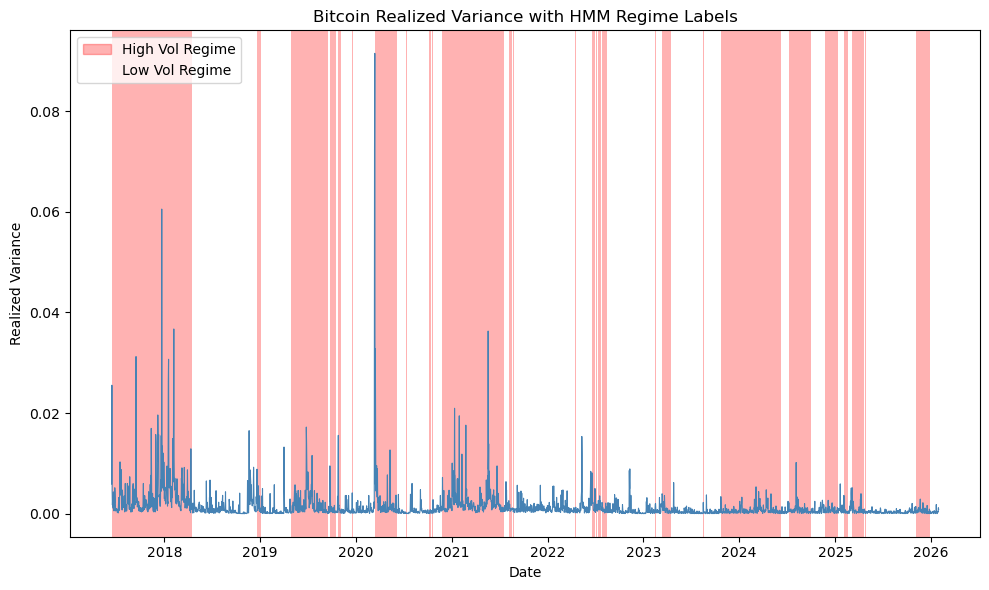

In [56]:
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
plot_df = df_hmm[df_hmm["hmm_regime"].notna()].copy()

ax.plot(plot_df["date"], plot_df["realized_variance"], color="steelblue", linewidth=0.8)
ax.set_ylabel("Realized Variance")
ax.set_xlabel("Date")
ax.set_title("Bitcoin Realized Variance with HMM Regime Labels")

in_high_vol = False
start_date  = None

for _, row in plot_df.iterrows():
    if row["hmm_regime"] == 1 and not in_high_vol:
        in_high_vol = True
        start_date  = row["date"]
    elif row["hmm_regime"] == 0 and in_high_vol:
        in_high_vol = False
        ax.axvspan(start_date, row["date"], alpha=0.3, color="red", linewidth=0)

if in_high_vol:
    ax.axvspan(start_date, plot_df["date"].iloc[-1], alpha=0.3, color="red", linewidth=0)

high_patch = mpatches.Patch(color="red",   alpha=0.3, label="High Vol Regime")
low_patch  = mpatches.Patch(color="white", alpha=0.3, label="Low Vol Regime")
ax.legend(handles=[high_patch, low_patch])
plt.tight_layout()
plt.show()